In [41]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [42]:
load_dotenv()

True

In [43]:
class BlogDict(TypedDict):
    title: str
    outline: str
    content: str
    score: int


In [44]:
model = ChatGroq(model="llama-3.3-70b-versatile")


In [45]:
def generate_outline(state: BlogDict) -> BlogDict:
    title = state["title"]
    prompt = f"Generate outline of blog for following title: {title}"
    outline = model.invoke(prompt).content
    state["outline"] = outline
    return state

def generate_content(state: BlogDict) -> BlogDict:
    outline = state["outline"]
    prompt2 = f"Generate content of blog for following outline: {outline}"
    content = model.invoke(prompt2).content
    state["content"] = content

    return state

def rate_content(state: BlogDict) -> BlogDict:
    content = state["content"]
    prompt3 = f"Rate the content of blog on scale of 1 to 10. Return ONLY the number without any explanation: {content}"    
    score = model.invoke(prompt3).content
    state["score"] = int(score)
    return state

In [46]:
graph = StateGraph(BlogDict)

graph.add_node("generate_outline", generate_outline)
graph.add_node("generate_content", generate_content)
graph.add_node("rate_content", rate_content)

graph.add_edge(START, "generate_outline")
graph.add_edge("generate_outline", "generate_content")
graph.add_edge("generate_content", "rate_content")
graph.add_edge("rate_content", END)

workflow = graph.compile()


In [47]:
initial_state = {"title": "Virat Kohli"}
final_state = workflow.invoke(initial_state)
print(final_state["outline"])


Here is a suggested outline for a blog on the title "Virat Kohli":

**I. Introduction**
- Brief overview of Virat Kohli
- Importance of Virat Kohli in Indian cricket
- Purpose of the blog

**II. Early Life and Career**
- Birth and upbringing
- Early interest in cricket
- Junior cricket career and achievements
- Rise to prominence in Indian cricket

**III. International Cricket Career**
- Debut and early years in international cricket
- Notable performances and milestones
- Achievements in different formats (Test, ODI, T20)
- Records and accolades

**IV. Captaincy and Leadership**
- Appointment as captain of the Indian team
- Leadership style and impact on the team
- Notable series and tournament wins under his captaincy
- Challenges faced and overcome as captain

**V. Personal Life and Philanthropy**
- Personal relationships and family
- Interests and hobbies outside of cricket
- Philanthropic efforts and charitable work
- Social media presence and influence

**VI. Legacy and Impact on

In [48]:
print(final_state["content"])

**The King of Indian Cricket: The Virat Kohli Story**

**Introduction**

In the world of cricket, few names evoke the same level of passion, dedication, and excellence as Virat Kohli. As one of the most successful and dominant players in the history of Indian cricket, Kohli has left an indelible mark on the sport. With a career spanning over a decade, he has consistently pushed the boundaries of what is possible, inspiring a generation of cricketers and fans alike. In this blog, we will delve into the life and career of Virat Kohli, exploring his early days, his rise to prominence, his achievements, and his lasting impact on Indian cricket.

**Early Life and Career**

Born on November 5, 1988, in Delhi, India, Virat Kohli was destined for greatness. Growing up in a middle-class family, Kohli's love affair with cricket began at a young age. His father, Prem Kohli, was a lawyer, and his mother, Saroj Kohli, was a homemaker. Kohli's early interest in cricket was encouraged by his family, 

In [49]:
print(final_state["score"])

8


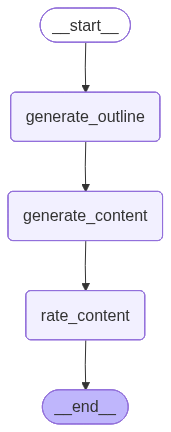

In [50]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())